In [4]:
from sklearn.datasets import fetch_20newsgroups

# Esto descargará los datos (aprox. 14MB) a tu carpeta ~/scikit_learn_data
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

In [5]:
newsgroups

{'data': ["\n\nI am sure some bashers of Pens fans are pretty confused about the lack\nof any kind of posts about the recent Pens massacre of the Devils. Actually,\nI am  bit puzzled too and a bit relieved. However, I am going to put an end\nto non-PIttsburghers' relief with a bit of praise for the Pens. Man, they\nare killing those Devils worse than I thought. Jagr just showed you why\nhe is much better than his regular season stats. He is also a lot\nfo fun to watch in the playoffs. Bowman should let JAgr have a lot of\nfun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final\nregular season game.          PENS RULE!!!\n\n",
  'My brother is in the market for a high-performance video card that supports\nVESA local bus with 1-2MB RAM.  Does anyone have suggestions/ideas on:\n\n  - Diamond Stealth Pro Local Bus\n\n  - Orchid Farenheit 1280\n\n  - ATI Graphics Ultra Pro\n\n  - Any othe

In [6]:
import pandas as pd

df_newsgroup = pd.DataFrame({
    'text': newsgroups.data,
    'target': newsgroups.target
})

# 3. Mapear los números de las categorías a sus nombres reales
df_newsgroup['target_name'] = df_newsgroup['target'].apply(lambda x: newsgroups.target_names[x])

df_newsgroup

,text,target,target_name
0,\n\nI am sure some bashers of Pens fans are pr...,10,rec.sport.hockey
1,My brother is in the market for a high-perform...,3,comp.sys.ibm.pc.hardware
2,\n\n\n\n\tFinally you said what you dream abou...,17,talk.politics.mideast
3,\nThink!\n\nIt's the SCSI card doing the DMA t...,3,comp.sys.ibm.pc.hardware
4,1) I have an old Jasmine drive which I cann...,4,comp.sys.mac.hardware
...,...,...,...
18841,DN> From: nyeda@cnsvax.uwec.edu (David Nye)\nD...,13,sci.med
18842,\nNot in isolated ground recepticles (usually ...,12,sci.electronics
18843,I just installed a DX2-66 CPU in a clone mothe...,3,comp.sys.ibm.pc.hardware
18844,\nWouldn't this require a hyper-sphere. In 3-...,1,comp.graphics


In [7]:
df_newsgroup.count()

text           18846
target         18846
target_name    18846
dtype: int64

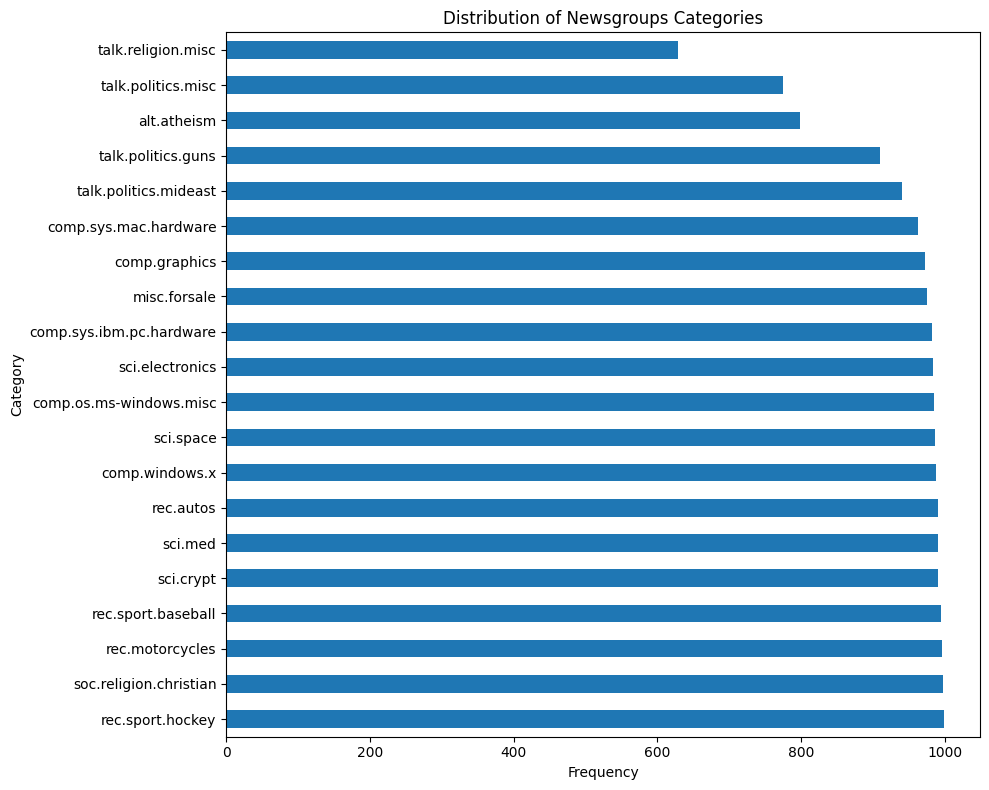

In [8]:
import matplotlib.pyplot as plt

df_newsgroup['target_name'].value_counts().plot(kind='barh', figsize=(10, 8))
plt.xlabel('Frequency')
plt.ylabel('Category')
plt.title('Distribution of Newsgroups Categories')
plt.tight_layout()
plt.show()

In [9]:
(print(df_newsgroup['text'].str.len().mean()))

1169.667515653189


In [11]:
import nltk
from nltk.tokenize import word_tokenize

# Descargar el tokenizer si es necesario
nltk.download('punkt', quiet=True)

# Tokenizar la columna 'text' de df_newsgroup
df_newsgroup['tokens'] = df_newsgroup['text'].apply(word_tokenize)
df_newsgroup['num_tokens'] = df_newsgroup['tokens'].apply(len)

# Calcular el promedio de tokens por fila
avg_tokens = df_newsgroup['num_tokens'].mean()
print(f"Average number of tokens per row: {avg_tokens:.2f}")

Average number of tokens per row: 253.06


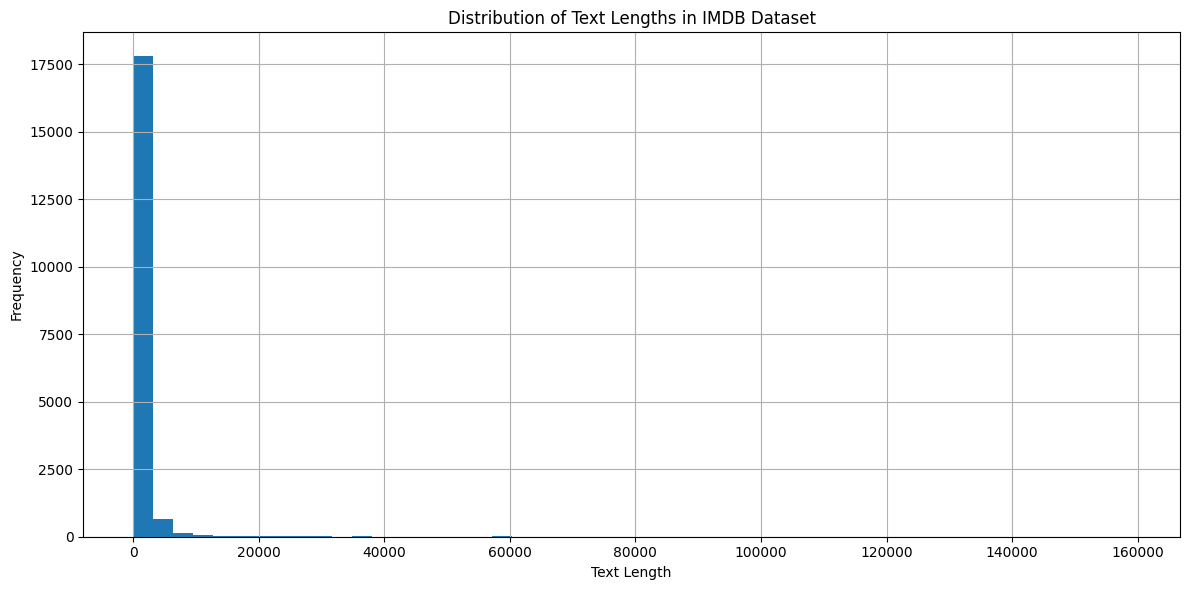

In [12]:
df_newsgroup['text'].str.len().hist(bins=50, figsize=(12, 6))
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.title('Distribution of Text Lengths in IMDB Dataset')
plt.tight_layout()
plt.show()

    Word  Frequency
0    the     173343
1     to      86509
2     of      76999
3      a      70354
4    and      69474
5     in      50430
6     is      48757
7      i      47515
8   that      44181
9     it      33988
10   for      32220
11   you      28104
12  this      23468
13    on      23271
14    be      21953
15  have      21301
16  with      20862
17   are      20818
18   not      20514
19    as      18689


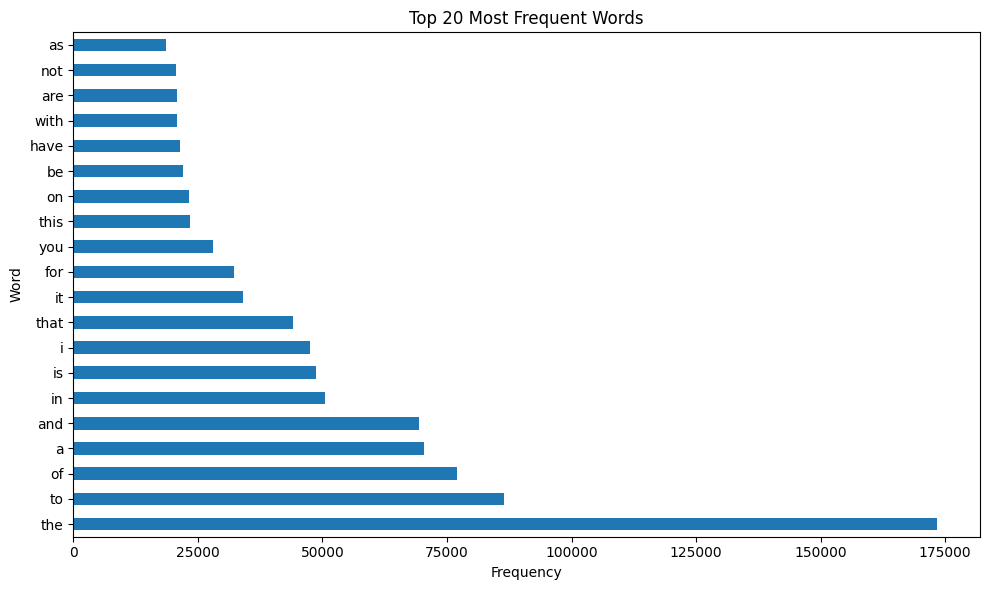

In [13]:
from collections import Counter
import string
import pandas as pd

# Clean text: lowercase and remove punctuation
def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

# Apply cleaning and tokenize
df_newsgroup['cleaned_tokens'] = df_newsgroup['text'].apply(lambda x: clean_text(x).split())

# Flatten all tokens and count frequencies
all_tokens = [token for tokens in df_newsgroup['cleaned_tokens'] for token in tokens if token.strip()]
token_counts = Counter(all_tokens)

# Get top 20 most frequent words
top_20 = token_counts.most_common(20)

# Display as dataframe for better visualization
top_20_df = pd.DataFrame(top_20, columns=['Word', 'Frequency'])
print(top_20_df)

# Optional: visualize as bar chart
top_20_df.plot(x='Word', y='Frequency', kind='barh', figsize=(10, 6), legend=False)
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.title('Top 20 Most Frequent Words')
plt.tight_layout()
plt.show()

In [14]:
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

df_newsgroup['text'] = df_newsgroup['text'].str.lower()
# Download stopwords if needed
nltk.download('stopwords', quiet=True)

# Get English stopwords
stop_words = set(stopwords.words('english'))

# Remove punctuation and stopwords
df_newsgroup['text'] = df_newsgroup['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words and word.isalpha()]))
# Download wordnet if needed
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Apply lemmatization
df_newsgroup['text'] = df_newsgroup['text'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()]))

[nltk_data] Error downloading 'stopwords' from
[nltk_data]     <https://raw.githubusercontent.com/nltk/nltk_data/gh-
[nltk_data]     pages/packages/corpora/stopwords.zip>:   <urlopen
[nltk_data]     error [Errno -2] Name or service not known>


LookupError: 
**********************************************************************
  Resource 'stopwords' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('stopwords')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'corpora/stopwords'

  Searched in:
    - '/home/ariel/nltk_data'
    - '/home/ariel/Escritorio/proyectos/nlp/.venv/nltk_data'
    - '/home/ariel/Escritorio/proyectos/nlp/.venv/share/nltk_data'
    - '/home/ariel/Escritorio/proyectos/nlp/.venv/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [ ]:
df_newsgroup['tokens'] = df_newsgroup['text'].apply(word_tokenize)
df_newsgroup['num_tokens'] = df_newsgroup['tokens'].apply(len)

print(df_newsgroup[['text', 'tokens', 'num_tokens']].head())

                                                text  \
0  sure bashers pen fan pretty confused lack kind...   
1  brother market video card support vesa local b...   
2  finally said dream area like july usa sweden a...   
3  scsi card dma transfer scsi card dma transfer ...   
4  old jasmine drive cannot use new understanding...   

                                              tokens  num_tokens  
0  [sure, bashers, pen, fan, pretty, confused, la...          57  
1  [brother, market, video, card, support, vesa, ...          26  
2  [finally, said, dream, area, like, july, usa, ...          81  
3  [scsi, card, dma, transfer, scsi, card, dma, t...          60  
4  [old, jasmine, drive, can, not, use, new, unde...          50  


In [ ]:
df_newsgroup.drop(columns=['num_tokens', 'cleaned_tokens'], inplace=True)
df_newsgroup.head()

,text,target,target_name,tokens
0,sure bashers pen fan pretty confused lack kind...,10,rec.sport.hockey,"[sure, bashers, pen, fan, pretty, confused, la..."
1,brother market video card support vesa local b...,3,comp.sys.ibm.pc.hardware,"[brother, market, video, card, support, vesa, ..."
2,finally said dream area like july usa sweden a...,17,talk.politics.mideast,"[finally, said, dream, area, like, july, usa, ..."
3,scsi card dma transfer scsi card dma transfer ...,3,comp.sys.ibm.pc.hardware,"[scsi, card, dma, transfer, scsi, card, dma, t..."
4,old jasmine drive cannot use new understanding...,4,comp.sys.mac.hardware,"[old, jasmine, drive, can, not, use, new, unde..."


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Create CountVectorizer with max_features=10000
vectorizer = CountVectorizer(max_features=10000)
bow_matrix = vectorizer.fit_transform(df_newsgroup['text'])

In [ ]:
# 2. TF-IDF
tfidf = TfidfVectorizer(max_features=10000)
tfidf_matrix = tfidf.fit_transform(df_newsgroup['text'])

In [ ]:
print(f"Bag of Words Matrix shape: {bow_matrix.shape}")
print(f"TF-IDF Matrix shape: {tfidf_matrix.shape}")

Bag of Words Matrix shape: (18846, 10000)
TF-IDF Matrix shape: (18846, 10000)


In [ ]:
import numpy as np

# Get feature names from the vectorizer
feature_names = vectorizer.get_feature_names_out()

# Display first 20 feature names
print("First 20 feature names from CountVectorizer:")
print(feature_names[:20])

# Display some random feature names
random_indices = np.random.choice(len(feature_names), 20, replace=False)
print("\nRandom 20 feature names:")
print(feature_names[random_indices])

First 20 feature names from CountVectorizer:
['aa' 'aaa' 'aaron' 'ab' 'abandon' 'abandoned' 'abbreviation' 'abc'
 'abiding' 'ability' 'able' 'aboard' 'abolish' 'abomination' 'abort'
 'abortion' 'abraham' 'abroad' 'abruptly' 'absence']

Random 20 feature names:
['train' 'ernie' 'motorcyclist' 'quark' 'condemned' 'imposing' 'judaism'
 'clutch' 'bat' 'hamilton' 'chair' 'cypherpunks' 'contradict' 'insertion'
 'guy' 'stem' 'unusual' 'christian' 'endless' 'chose']


Accuracy: 0.6655
Precision: 0.6797
Recall: 0.6655
F1-Score: 0.6660


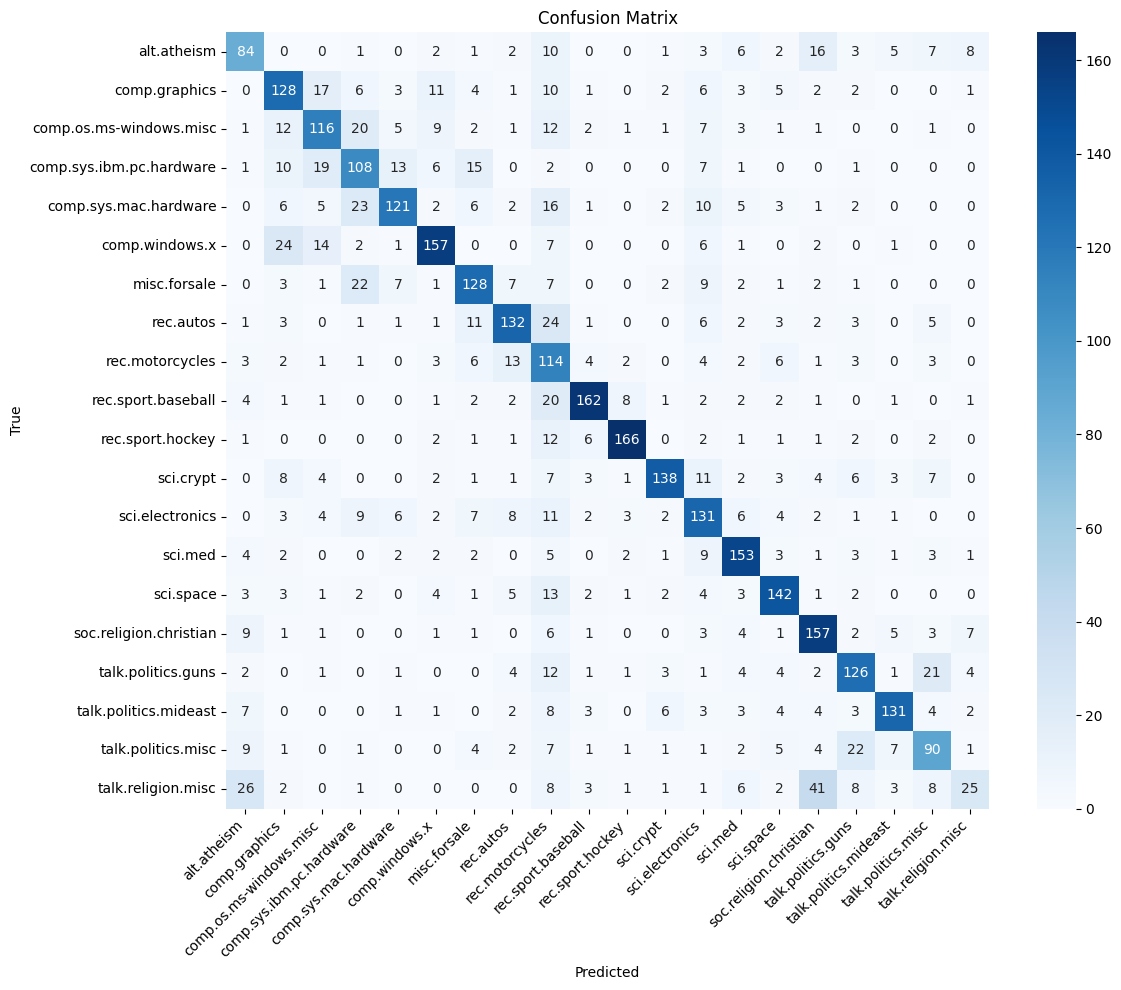

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

# Split the TF-IDF matrix and target into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    tfidf_matrix, df_newsgroup['target'], test_size=0.2, random_state=42
)

# Train Logistic Regression classifier
lr_classifier = LogisticRegression(max_iter=1000, random_state=42)
lr_classifier.fit(X_train, y_train)

# Make predictions
y_pred = lr_classifier.predict(X_test)

# Evaluate using accuracy, precision, recall, and F1-score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=newsgroups.target_names, yticklabels=newsgroups.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Accuracy: 0.6138
Precision: 0.6291
Recall: 0.6138
F1-Score: 0.6178


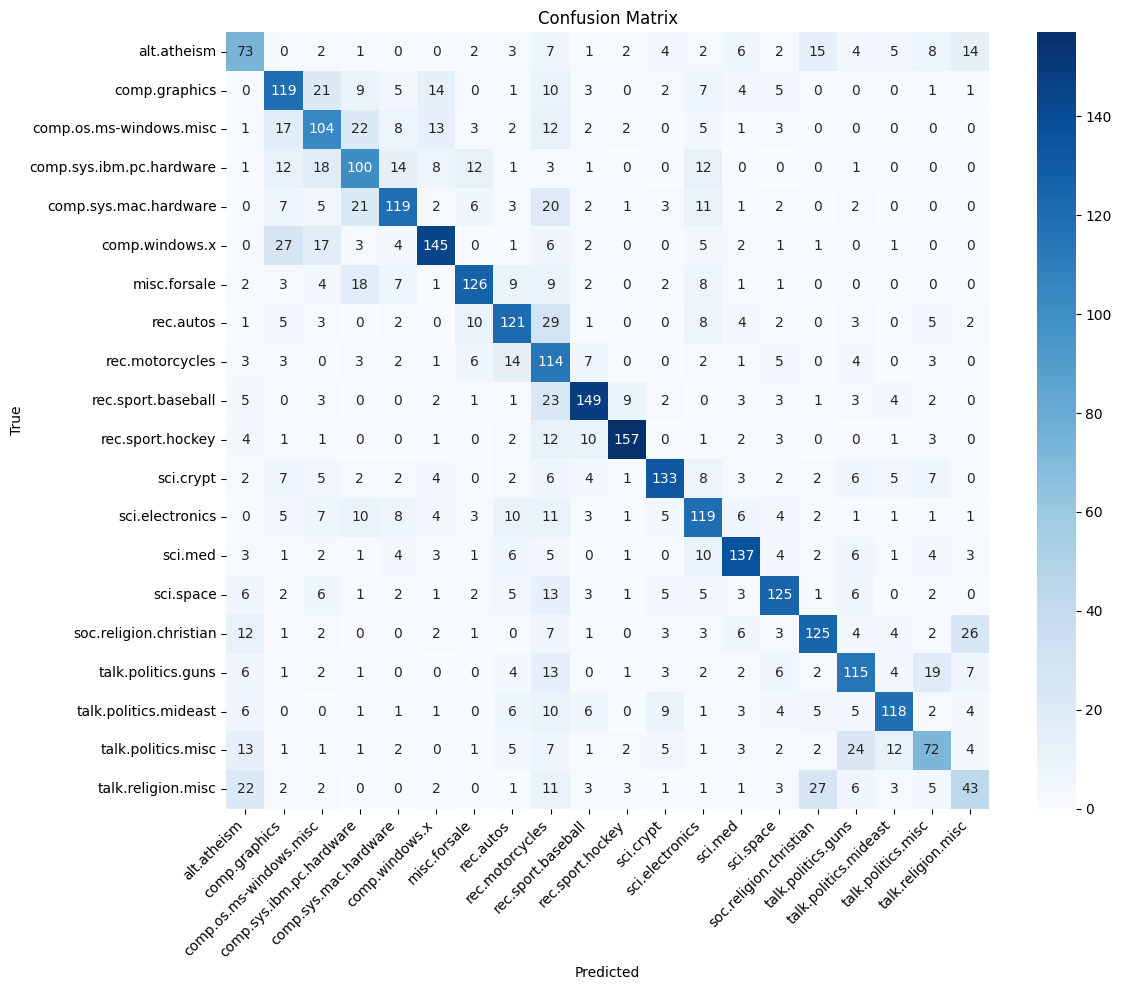

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

# Split the TF-IDF matrix and target into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    bow_matrix, df_newsgroup['target'], test_size=0.2, random_state=42
)

# Train Logistic Regression classifier
lr_classifier = LogisticRegression(max_iter=1000, random_state=42)
lr_classifier.fit(X_train, y_train)

# Make predictions
y_pred = lr_classifier.predict(X_test)

# Evaluate using accuracy, precision, recall, and F1-score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=newsgroups.target_names, yticklabels=newsgroups.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from datasets import load_dataset

# Descarga y carga el dataset
dataset_imdb = load_dataset("imdb")

# Ver la estructura
print(dataset_imdb)

In [ ]:
dataset_imdb.set_format(type="pandas")
df_imdb_train = dataset_imdb["train"][:]
df_imdb_test = dataset_imdb["test"][:]
df_imdb = pd.concat([df_imdb_train, df_imdb_test], ignore_index=True)
df_imdb.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [ ]:
df_imdb.count()

text     50000
label    50000
dtype: int64

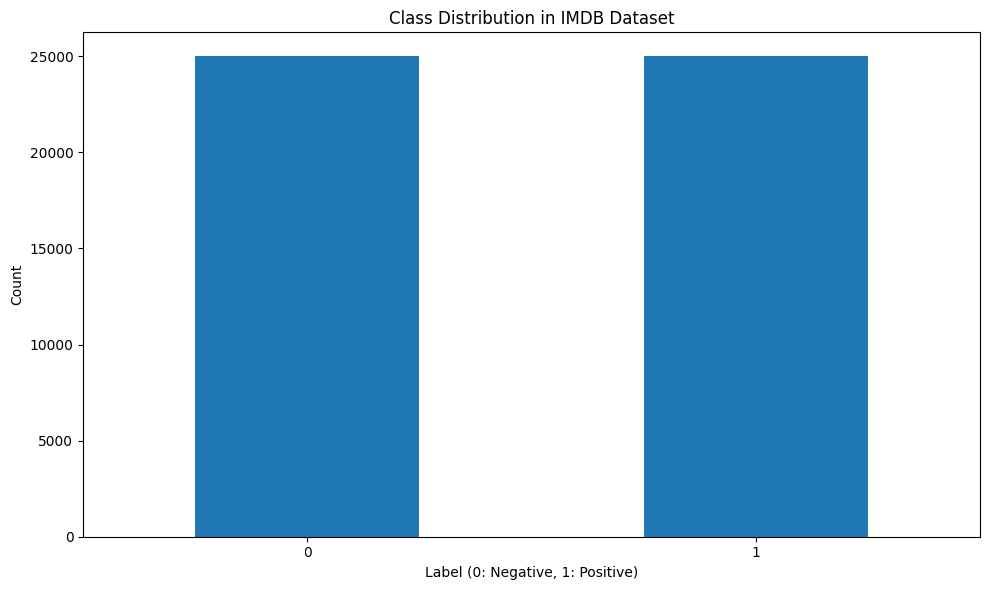

label
0    25000
1    25000
Name: count, dtype: int64


In [ ]:
# Show class distribution for IMDB dataset
df_imdb['label'].value_counts().sort_index().plot(kind='bar', figsize=(10, 6))
plt.xlabel('Label (0: Negative, 1: Positive)')
plt.ylabel('Count')
plt.title('Class Distribution in IMDB Dataset')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(df_imdb['label'].value_counts())

In [ ]:
# Calculate average text length in characters
avg_text_length_chars = df_imdb['text'].str.len().mean()

# Tokenize and calculate average number of tokens
df_imdb['tokens'] = df_imdb['text'].apply(word_tokenize)
avg_text_length_tokens = df_imdb['tokens'].apply(len).mean()

print(f"Average text length (characters): {avg_text_length_chars:.2f}")
print(f"Average text length (tokens): {avg_text_length_tokens:.2f}")

Average text length (characters): 1309.43
Average text length (tokens): 279.48


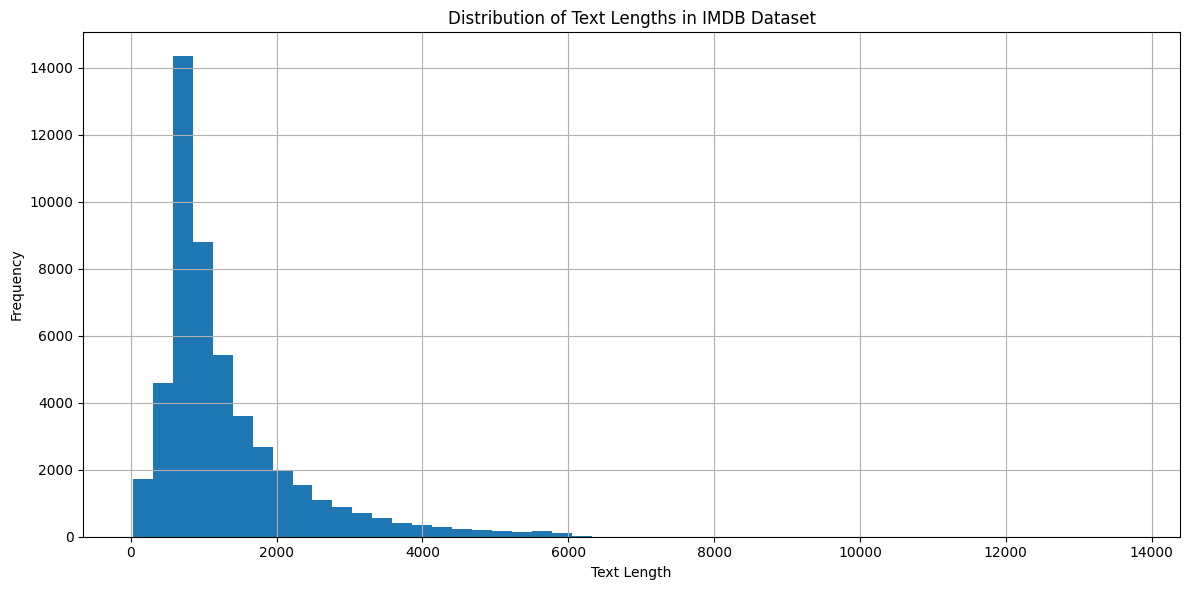

     Word  Frequency
0     the     663815
1     and     320663
2       a     320517
3      of     288382
4      to     266773
5      is     210161
6      in     184861
7      it     152899
8       i     152092
9    this     149405
10   that     136092
11     br     113794
12    was      95223
13     as      91231
14   with      86846
15    for      86726
16  movie      83510
17    but      81766
18   film      74453
19     on      66663


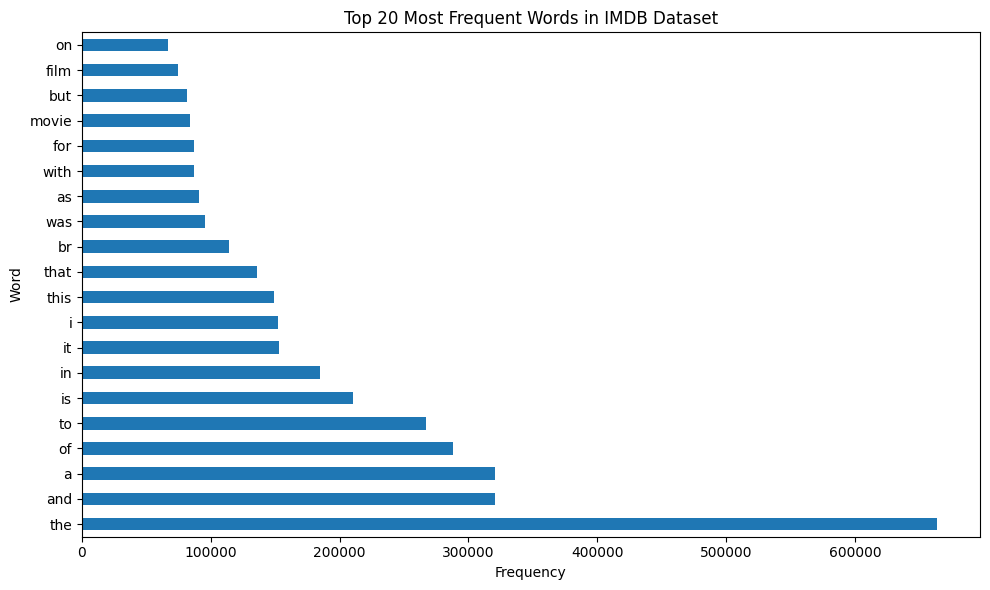

In [ ]:
from collections import Counter
import string

# Plot histogram of text lengths for IMDB dataset
df_imdb['text'].str.len().hist(bins=50, figsize=(12, 6))
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.title('Distribution of Text Lengths in IMDB Dataset')
plt.tight_layout()
plt.show()

# Display top 20 most frequent words after basic cleaning

def clean_text_simple(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text.split()

# Apply cleaning and tokenize
df_imdb['cleaned_tokens_simple'] = df_imdb['text'].apply(clean_text_simple)

# Flatten all tokens and count frequencies
all_tokens_imdb = [token for tokens in df_imdb['cleaned_tokens_simple'] for token in tokens if token.strip()]
token_counts_imdb = Counter(all_tokens_imdb)

# Get top 20 most frequent words
top_20_imdb = token_counts_imdb.most_common(20)

# Display as dataframe for better visualization
top_20_imdb_df = pd.DataFrame(top_20_imdb, columns=['Word', 'Frequency'])
print(top_20_imdb_df)

# Visualize as bar chart
top_20_imdb_df.plot(x='Word', y='Frequency', kind='barh', figsize=(10, 6), legend=False)
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.title('Top 20 Most Frequent Words in IMDB Dataset')
plt.tight_layout()
plt.show()

In [ ]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# Get English stopwords
stop_words_en = set(stopwords.words('english'))

# Initialize lemmatizer
lemmatizer_imdb = WordNetLemmatizer()

# Process text: lowercase, tokenize, remove stopwords and punctuation, lemmatize
def process_imdb_text(text):
    # Lowercase
    text = text.lower()
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and punctuation
    tokens = [token for token in tokens if token not in stop_words_en and token not in string.punctuation]
    # Lemmatize
    tokens = [lemmatizer_imdb.lemmatize(token) for token in tokens]
    return ' '.join(tokens)

# Apply to IMDB dataset
df_imdb['text'] = df_imdb['text'].apply(process_imdb_text)

df_imdb.head()

,text,label,tokens,cleaned_tokens_simple
0,rented curious-yellow video store controversy ...,0,"[I, rented, I, AM, CURIOUS-YELLOW, from, my, v...","[i, rented, i, am, curiousyellow, from, my, vi..."
1,`` curious yellow '' risible pretentious steam...,0,"[``, I, Am, Curious, :, Yellow, '', is, a, ris...","[i, am, curious, yellow, is, a, risible, and, ..."
2,avoid making type film future film interesting...,0,"[If, only, to, avoid, making, this, type, of, ...","[if, only, to, avoid, making, this, type, of, ..."
3,film probably inspired godard 's masculin fémi...,0,"[This, film, was, probably, inspired, by, Goda...","[this, film, was, probably, inspired, by, goda..."
4,oh brother ... hearing ridiculous film umpteen...,0,"[Oh, ,, brother, ..., after, hearing, about, t...","[oh, brotherafter, hearing, about, this, ridic..."


In [ ]:
# Tokenize IMDB text
df_imdb['tokens'] = df_imdb['text'].apply(word_tokenize)

# Apply Bag of Words (CountVectorizer) to IMDB data
vectorizer_imdb = CountVectorizer(max_features=10000)
bow_matrix_imdb = vectorizer_imdb.fit_transform(df_imdb['text'])

# Apply TF-IDF Vectorizer to IMDB data
tfidf_imdb = TfidfVectorizer(max_features=10000)
tfidf_matrix_imdb = tfidf_imdb.fit_transform(df_imdb['text'])

print(f"Bag of Words Matrix shape: {bow_matrix_imdb.shape}")
print(f"TF-IDF Matrix shape: {tfidf_matrix_imdb.shape}")

Bag of Words Matrix shape: (50000, 10000)
TF-IDF Matrix shape: (50000, 10000)


In [ ]:
# Get feature names from the TF-IDF vectorizer for IMDB data
feature_names_imdb = tfidf_imdb.get_feature_names_out()

# Display first 20 feature names
print("First 20 feature names from TF-IDF Vectorizer (IMDB):")
print(feature_names_imdb[:20])

# Display some random feature names
random_indices_imdb = np.random.choice(len(feature_names_imdb), 20, replace=False)
print("\nRandom 20 feature names:")
print(feature_names_imdb[random_indices_imdb])

First 20 feature names from TF-IDF Vectorizer (IMDB):
['00' '000' '007' '10' '100' '1000' '101' '11' '12' '13' '13th' '14' '15'
 '150' '16' '17' '18' '18th' '19' '1920']

Random 20 feature names:
['rapist' 'sorta' 'abused' 'noticing' 'cannibal' 'edgar' 'elia' 'gotten'
 'synopsis' 'binoche' 'program' 'focus' 'pornographic' 'adopted' 'esteem'
 'innocent' 'damon' '2001' 'lifeforce' 'policeman']


Accuracy: 0.8914
Precision: 0.8917
Recall: 0.8914
F1-Score: 0.8914


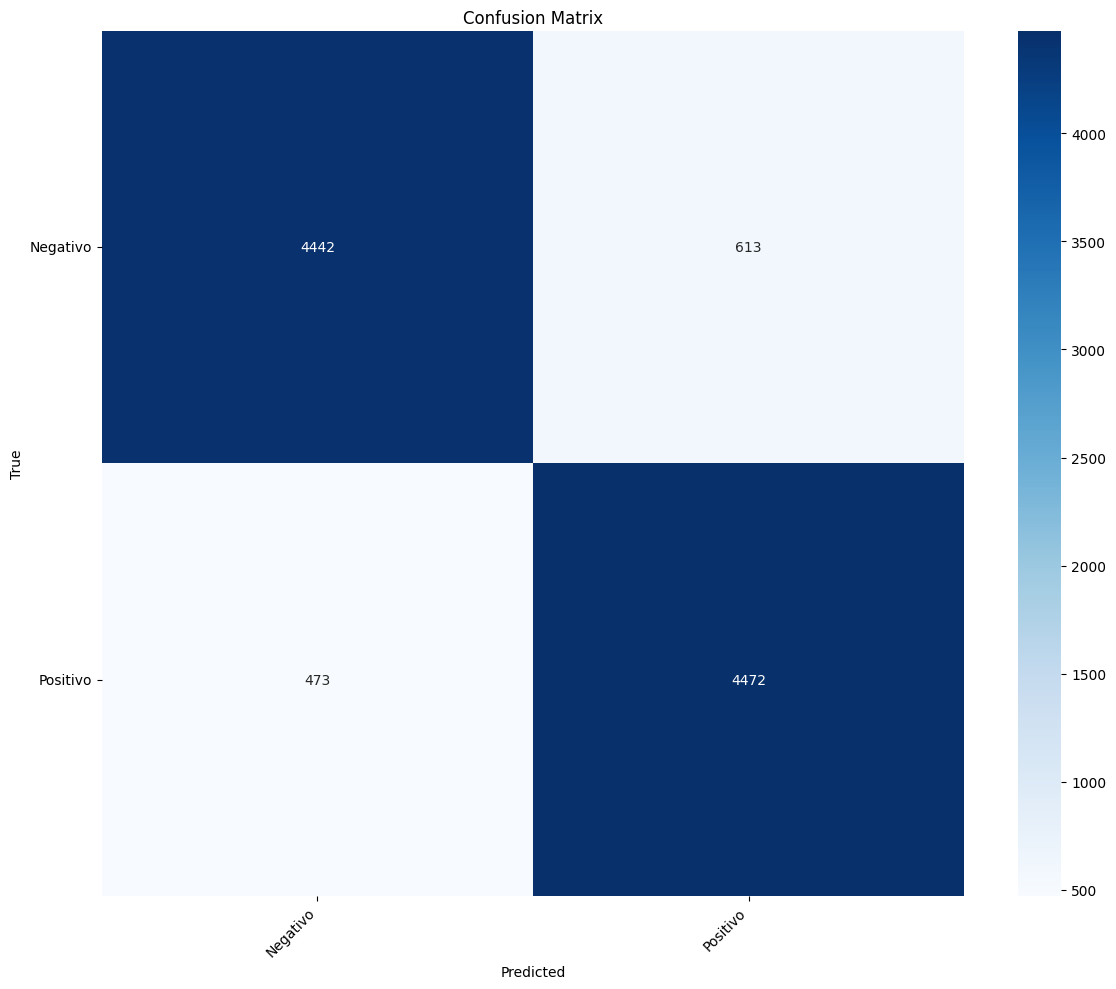

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

# Split the TF-IDF matrix and target into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    tfidf_matrix_imdb, df_imdb['label'], test_size=0.2, random_state=42
)

# Train Logistic Regression classifier
lr_classifier = LogisticRegression(max_iter=1000, random_state=42)
lr_classifier.fit(X_train, y_train)

# Make predictions
y_pred = lr_classifier.predict(X_test)

# Evaluate using accuracy, precision, recall, and F1-score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

etiquetas = ['Negativo', 'Positivo']

# Display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=etiquetas, yticklabels=etiquetas)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Accuracy: 0.8707
Precision: 0.8708
Recall: 0.8707
F1-Score: 0.8707


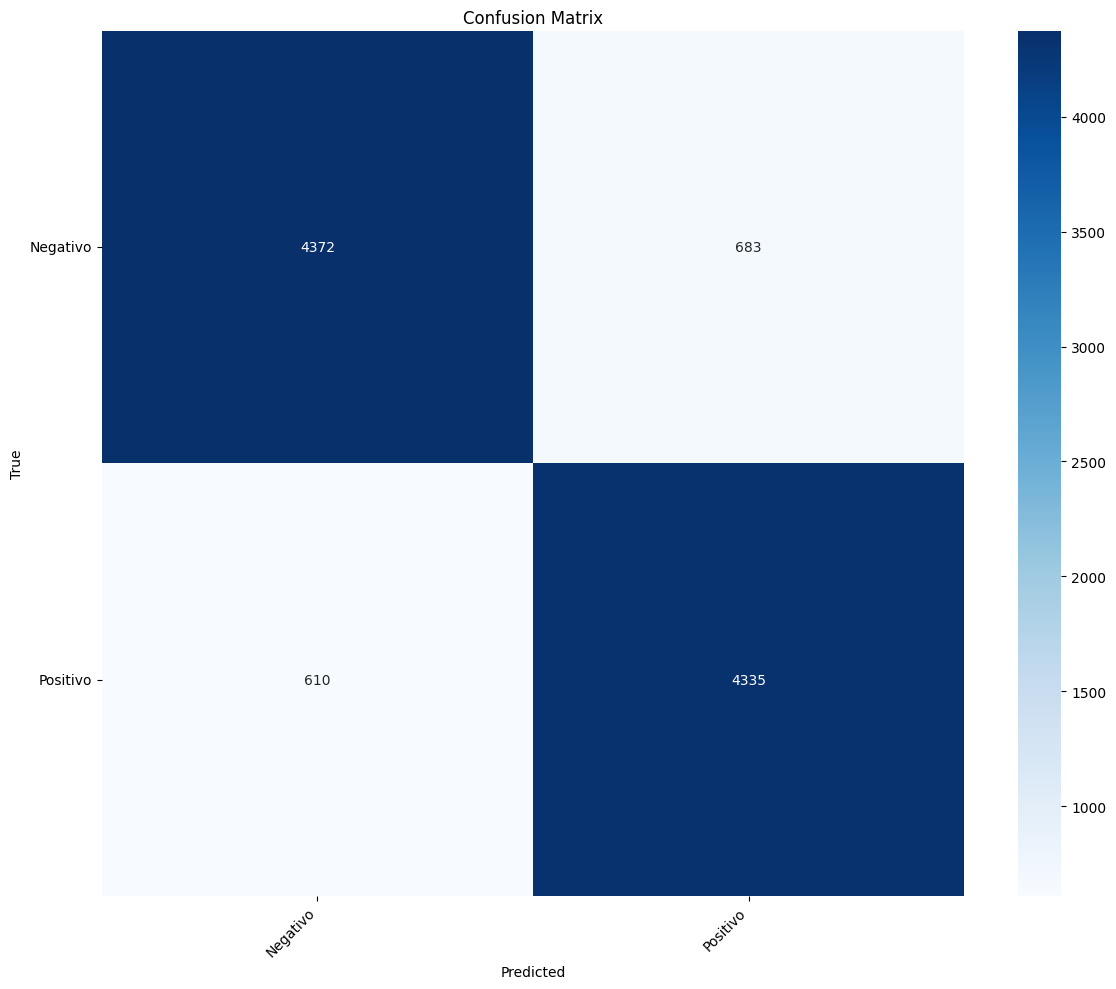

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

# Split the TF-IDF matrix and target into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    bow_matrix_imdb, df_imdb['label'], test_size=0.2, random_state=42
)

# Train Logistic Regression classifier
lr_classifier = LogisticRegression(max_iter=1000, random_state=42)
lr_classifier.fit(X_train, y_train)

# Make predictions
y_pred = lr_classifier.predict(X_test)

# Evaluate using accuracy, precision, recall, and F1-score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

etiquetas = ['Negativo', 'Positivo']

# Display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=etiquetas, yticklabels=etiquetas)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

While CountVectorizer simply tallies word frequencies, making it prone to noise from common terms, TF-IDF assigns higher weights to distinctive, meaningful words by penalizing those that appear across the entire dataset, which typically leads to superior model performance in text classification. This performance gap exists because TF-IDF effectively filters out uninformative "stop words" and normalizes for document length, allowing the Logistic Regression model to focus on the most relevant features. To further improve results, you could implement N-grams to capture context like "not good," or transition to Word Embeddings (such as Word2Vec or GloVe) to represent semantic relationships between words that sparse matrices like Bag-of-Words and TF-IDF inherently ignore.